# Proyecto Final: Análsis Discriminante Lineal y Cuadrático

**Versión para estudiantes.**  
Completa las líneas marcadas con `# TU CÓDIGO AQUÍ`, respetando el orden de la versión completa.


##Introducción

El **análisis discriminante** es una familia de métodos estadísticos utilizados para resolver problemas de **clasificación supervisada**. Su objetivo es asignar una observación a una clase o grupo a partir de un conjunto de variables predictoras.

En este proyecto se aplican dos modelos:

### Análisis Discriminante Lineal, LDA

Es un modelo de clasificación supervisado que busca encontrar una combinación lineal de variables independientes que permita separar de manera óptima dos o más clases de una variable categórica dependiente.

Además, LDA supone que todas las clases comparten una misma matriz de covarianzas:

$$
\Sigma_1 = \Sigma_2 = \cdots = \Sigma_K = \Sigma$$

Por esta razón, genera fronteras de decisión **lineales**.

### Análisis Discriminante Cuadrático, QDA

QDA permite que cada clase tenga su propia matriz de covarianzas:

$$
\Sigma_k \neq \Sigma_l
$$

Por eso puede generar fronteras de decisión **cuadráticas**. Esto lo hace más flexible que LDA, pero también puede aumentar el riesgo de sobreajuste.
### Datos

Para realizar este proyecto, aplicamos los modelos de **Análisis Discriminante Lineal (LDA)** y **Análisis Discriminante Cuadrático (QDA)** a la base **Pima Indians Diabetes**.

Este conjunto de datos proviene originalmente del Instituto Nacional de Diabetes y Enfermedades Digestivas y Renales.

El objetivo es clasificar a las pacientes en dos grupos:

- `0`: No presenta diabetes.
- `1`: Presenta diabetes.

La base contiene variables clínicas numéricas como `glucosa`, `presión arterial`, `insulina`, `IMC` y `edad`.

### Pregunta de concepto 1
Explica con tus palabras cuál es la diferencia principal entre LDA y QDA.

> Escribe tu respuesta aquí:la diferencias es que LDA supone que todas las clases comparten la misma matriz de covarianza mientras que QDA permite una matriz de covarianza diferente para cada clase


### Librerías

In [1]:
# Librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Carga de datos

**Pregunta 2.** ¿Qué tipo de archivo se está cargando y qué función de `pandas` se utiliza para leerlo?

> Escribe tu respuesta aquí: se esta cargando un archivo CSV y se utiliza la funcion pd.read_csv() para leerlo


In [3]:
#Carga de datos
df = pd.read_csv('/content/drive/MyDrive/ciencicias de datos/modulo 4/Tareas/clase 4/diabetes.csv')

### Información general de la base

**Pregunta 3.** ¿Por qué es importante revisar la estructura general de la base antes de modelar?

> Escribe tu respuesta aquí:porque permite conocer las variables de la base detectar posibles errores y verificar que los datos esten listos para entrenar el modelo asi que es muy bueno revisar ya que asi podemos ver errores que tenga antes y que no de problemas cuando estemos mas avanzados


In [4]:
# Mostrar primeras filas
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
#Información General
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
# Estadísticos descriptivos
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [7]:
#Valores faltantes
df.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [8]:
# Conteo de clases
df["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


In [9]:
# Frecuencias relativas de clases
df["Outcome"].value_counts(normalize=True)

,proportion
Outcome,
0,0.651042
1,0.348958


La variable `Outcome` es la variable respuesta:

- `0`: paciente sin diabetes.
- `1`: paciente con diabetes.



**Pregunta 4.** ¿Qué significa que `Outcome = 0` y `Outcome = 1`?

> Escribe tu respuesta aquí: el 0 es pacientes que no tiene diabetes y 1 lo que si tiene diabetes


### Análisis exploratorio de los datos

**Pregunta 5.** ¿Qué patrones observas en las gráficas exploratorias? ¿Alguna variable parece separar mejor a las clases?

> Escribe tu respuesta aquí:se observa que hay mas pacientes sin diabetes que con diabetes


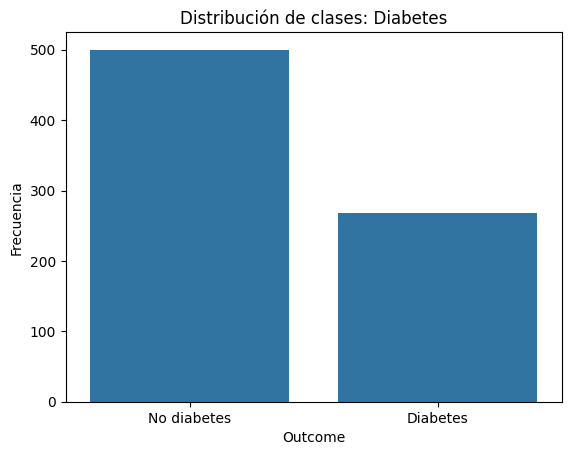

In [12]:
#Distribución General
sns.countplot(x='Outcome',data=df)
plt.title("Distribución de clases: Diabetes")
plt.xlabel("Outcome")
plt.ylabel("Frecuencia")
plt.xticks([0, 1], ["No diabetes", "Diabetes"])
plt.show()

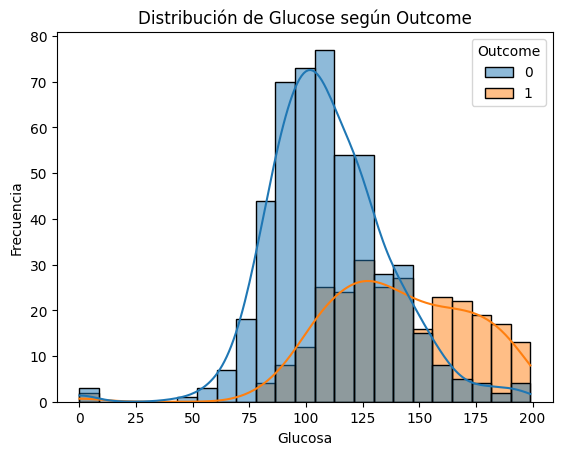

In [13]:
#Histograma de glucosa por clase
sns.histplot(data=df,
             x="Glucose",
             hue="Outcome",
             kde=True)

plt.title("Distribución de Glucose según Outcome")
plt.xlabel("Glucosa")
plt.ylabel("Frecuencia")
plt.show()

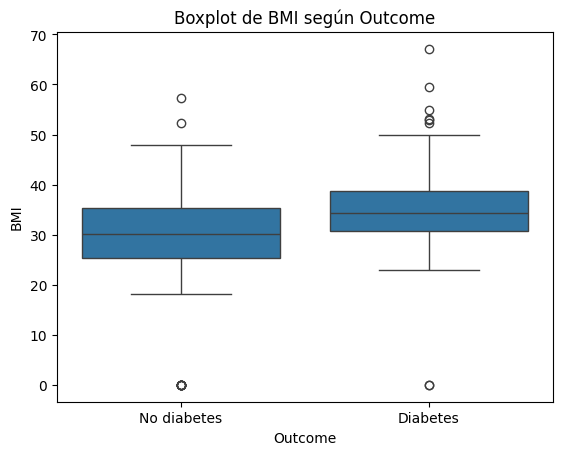

In [15]:
# Boxplot de BMI por clase
sns.boxplot(
    x= "Outcome",
    y='BMI',
    data=df
)

plt.title("Boxplot de BMI según Outcome")
plt.xlabel("Outcome")
plt.ylabel("BMI")
plt.xticks([0, 1], ["No diabetes", "Diabetes"])
plt.show()

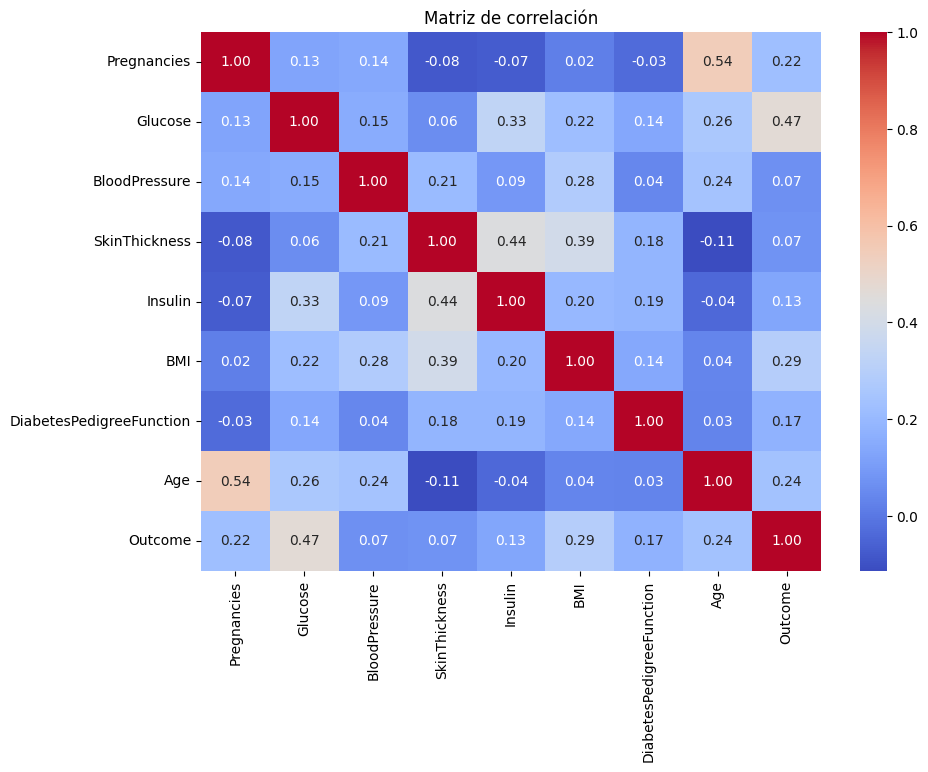

In [16]:
#Matriz de Correlación
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación")
plt.show()

## **PASO 1.** Preparación de los datos.

**Pregunta 6.** ¿Por qué se separan las variables predictoras `X` de la variable respuesta `y`?

> Escribe tu respuesta aquí: se separan X y y para que el modelo pueda aprender la relacion entre las variables de entrada y la variable objetivo y asi despues hacer predicciones correctamente


In [17]:
# Variables Predictorias
X = df.drop(columns="Outcome")

y = df["Outcome"]

In [18]:
# División de emtrenamiento / Prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=123,
    stratify=y
)

Se dividió la base de datos en un conjunto de entrenamiento y un conjunto de prueba. El conjunto de entrenamiento se utilizó para estimar los parámetros de los modelos LDA y QDA, mientras que el conjunto de prueba se reservó para evaluar su desempeño predictivo.

## **PASO 2.** Probabilidades previas (prior probabilities)

Las probabilidades previas son la proporción de observaciones que pertenecen a cada grupo antes de observar las variables predictoras.

En este caso se calculan usando el conjunto de entrenamiento.

**Pregunta 7.** ¿Qué representan las probabilidades previas en un modelo de clasificación?

> Escribe tu respuesta aquí: representan la proporcion de observaciones que pertenece a cada clase antes de considerar las variables predictoras


In [19]:

prior_probabilities = y_train.value_counts(normalize=True).sort_index()

tabla_priors = pd.DataFrame({
    "Clase": ["No diabetes", "Diabetes"],
    "Probabilidad previa": prior_probabilities.values
})

tabla_priors

,Clase,Probabilidad previa
0,No diabetes,0.651769
1,Diabetes,0.348231


In [21]:
priors = prior_probabilities.values
priors

array([0.65176909, 0.34823091])

## **Paso 3.** Comparación de matrices de covarianza

Este paso ayuda a discutir si el supuesto de LDA parece razonable.

- Si las matrices de covarianzas son parecidas, LDA puede ser adecuado.
- Si las matrices de covarianzas son diferentes, QDA puede ser una alternativa útil.


**Pregunta 8.** Si las matrices de covarianza fueran muy diferentes entre clases, ¿qué modelo podría tener ventaja teórica: LDA o QDA?

> Escribe tu respuesta aquí: QDA tendria ventaja porque permite que cada clase tenga su propia matriz de covarianza mientras que LDA son iguales


In [22]:
# Unimos X_train con y_train para poder separar por grupo
train_data = X_train.copy().reset_index(drop=True)
train_data["Outcome"] = y_train.reset_index(drop=True)

# Matriz de covarianzas para el grupo sin diabetes
cov_no_diabetes = train_data[train_data["Outcome"] == 0].drop(columns="Outcome",axis=1).cov()

# Matriz de covarianzas para el grupo con diabetes
cov_diabetes = train_data[train_data["Outcome"] == 1].drop(columns="Outcome",axis=1).cov()

print("Matriz de covarianzas - No diabetes")
display(cov_no_diabetes)

print("Matriz de covarianzas - Diabetes")
display(cov_diabetes)

Matriz de covarianzas - No diabetes


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,9.939623,12.002988,9.482481,-3.131805,-39.380106,0.560851,-0.068295,23.124273
Glucose,12.002988,636.471560,79.815383,-10.703725,848.308866,22.591054,0.415552,83.201654
BloodPressure,9.482481,79.815383,331.168244,60.546132,146.224494,60.433465,0.306085,47.444683
SkinThickness,-3.131805,-10.703725,60.546132,224.676218,634.381662,50.352378,0.492062,-26.000573
Insulin,-39.380106,848.308866,146.224494,634.381662,9298.979812,199.764933,3.627588,-188.228031
BMI,0.560851,22.591054,60.433465,50.352378,199.764933,64.884231,0.150221,4.378759
DiabetesPedigreeFunction,-0.068295,0.415552,0.306085,0.492062,3.627588,0.150221,0.088690,0.218711
Age,23.124273,83.201654,47.444683,-26.000573,-188.228031,4.378759,0.218711,150.206500


Matriz de covarianzas - Diabetes


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Pregnancies,14.347479,-6.146196,13.492812,-8.912598,-65.272670,-6.640429,-0.158572,17.361566
Glucose,-6.146196,1106.323443,39.536456,24.859065,1256.375970,19.609318,1.044496,43.069662
BloodPressure,13.492812,39.536456,469.606808,80.438848,117.882410,23.033376,-0.148588,61.349060
SkinThickness,-8.912598,24.859065,80.438848,304.854580,1145.622362,44.451734,1.440654,-41.030159
Insulin,-65.272670,1256.375970,117.882410,1145.622362,18784.719338,51.508131,0.177010,17.284687
BMI,-6.640429,19.609318,23.033376,44.451734,51.508131,62.758868,0.405342,-18.286643
DiabetesPedigreeFunction,-0.158572,1.044496,-0.148588,1.440654,0.177010,0.405342,0.143081,-0.526248
Age,17.361566,43.069662,61.349060,-41.030159,17.284687,-18.286643,-0.526248,119.657409


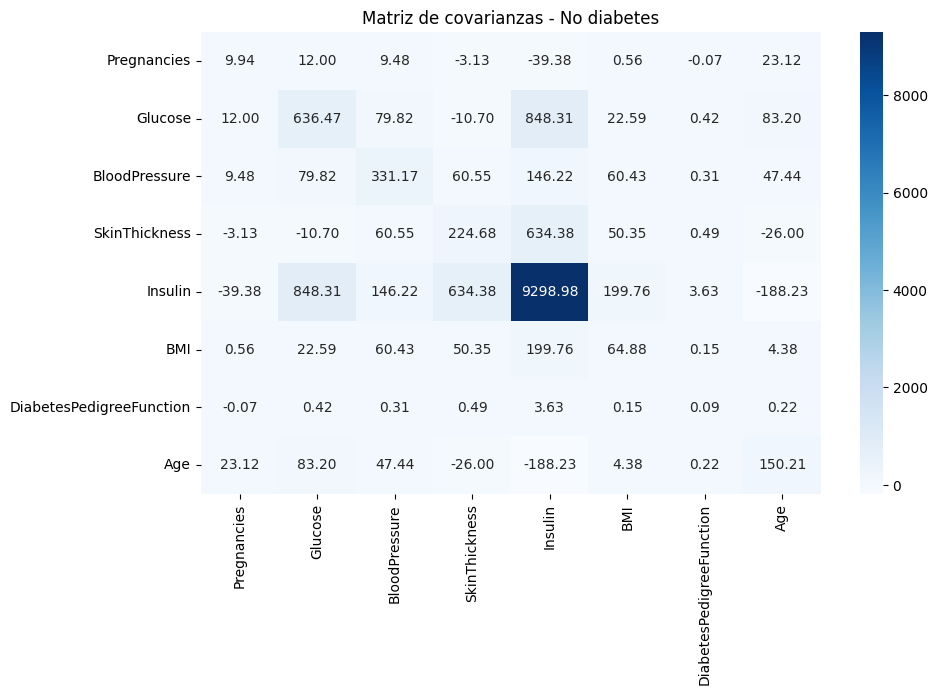

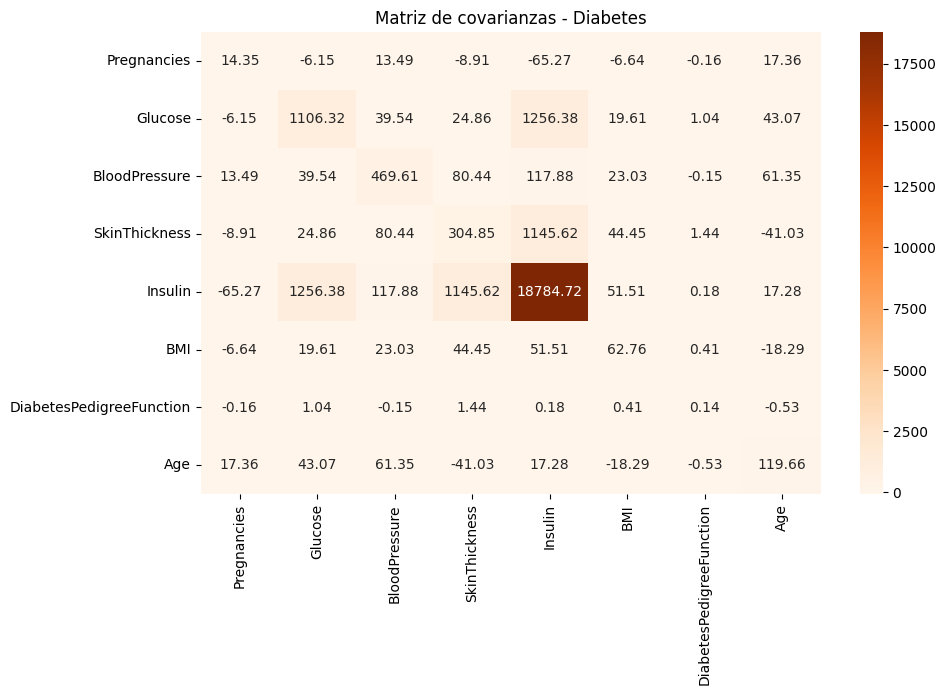

In [23]:
plt.figure(figsize=(10, 6))
sns.heatmap(cov_no_diabetes, annot=True, fmt=".2f", cmap="Blues")
plt.title("Matriz de covarianzas - No diabetes")
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(cov_diabetes, annot=True, fmt=".2f", cmap="Oranges")
plt.title("Matriz de covarianzas - Diabetes")
plt.show()

In [24]:
# Comparación de varianzas por variable

varianzas_comparacion = pd.DataFrame({
    "Variable": X_train.columns,
    "Varianza No diabetes": np.diag(cov_no_diabetes),
    "Varianza Diabetes": np.diag(cov_diabetes)
})

varianzas_comparacion["Diferencia absoluta"] = abs(
    varianzas_comparacion["Varianza No diabetes"] -
    varianzas_comparacion["Varianza Diabetes"]
)

varianzas_comparacion

,Variable,Varianza No diabetes,Varianza Diabetes,Diferencia absoluta
0,Pregnancies,9.939623,14.347479,4.407855
1,Glucose,636.471560,1106.323443,469.851884
2,BloodPressure,331.168244,469.606808,138.438564
3,SkinThickness,224.676218,304.854580,80.178362
4,Insulin,9298.979812,18784.719338,9485.739526
5,BMI,64.884231,62.758868,2.125363
6,DiabetesPedigreeFunction,0.088690,0.143081,0.054391
7,Age,150.206500,119.657409,30.549091


En este paso se calcularon las matrices de covarianza para los dos grupos de la variable `Outcome`: pacientes sin diabetes y pacientes con diabetes.
La comparación de varianzas muestra que algunas variables, como Glucose e Insulin, presentan diferencias importantes entre los grupos con y sin diabetes. Esto sugiere que las matrices de covarianza no son completamente homogéneas, por lo que QDA podría considerarse como una alternativa teórica.

## **Paso 4.** Implementación del Modelo LDA



**Pregunta 9.** ¿Qué supuesto sobre las matrices de covarianza utiliza LDA?

> Escribe tu respuesta aquí: LDA supone que todas las clases comparten la misma matriz de covarianza aunque las medias de cada clase pueden ser diferentes


In [36]:
# Modelo LDA
lda_model = LinearDiscriminantAnalysis()
lda_model.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [40]:
# Predicciones
lda_pred = lda_model.predict(X_test)

## **Paso 5.** Implementación del Modelo QDA

**Pregunta 10.** ¿Por qué QDA puede ser más flexible que LDA?

> Escribe tu respuesta aquí: porque permite que cada clase tenga su propia matriz de covarianza lo que le permite adaptarse mejor cuando las clases presentan patrones diferentes


In [42]:
# Modelo QDA
qda_model = QuadraticDiscriminantAnalysis()
qda_model.fit(X_train, y_train)

QuadraticDiscriminantAnalysis()

In [43]:
# Predicciones
qda_pred = qda_model.predict(X_test)

## **Paso 6.** Evaluación del desempeño de LDA

Se evalúa el modelo con:

- Accuracy
- Precision
- Recall
- F1-score
- Matriz de confusión
- Curva ROC
- AUC

**Pregunta 11.** ¿Por qué no conviene evaluar el modelo únicamente con accuracy?

> Escribe tu respuesta aquí:  no conviene usar solo accuracy porque puede dar una idea equivocada del desempeño del modelo especialmente cuando las clases no estan balanceadas


#### Matriz de confusión

In [44]:
# Matriz de confusión LDA
cm_lda = pd.crosstab(
    y_test,
    lda_pred,
    rownames=['Real'],
    colnames=['Predicción']
)

cm_lda

Predicción,0,1
Real,,
0,132,18
1,39,42


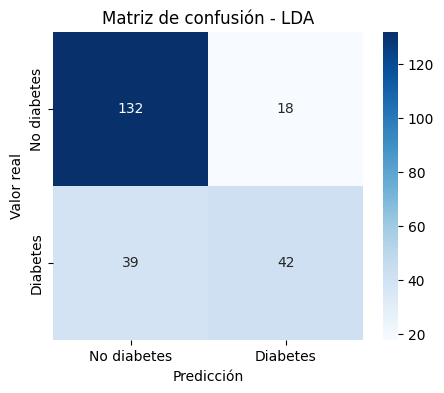

In [45]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_lda,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No diabetes", "Diabetes"],
    yticklabels=["No diabetes", "Diabetes"]
)

plt.title("Matriz de confusión - LDA")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

La matriz de confusión permite identificar los aciertos y errores de clasificación.

- Verdadero negativo: paciente sin diabetes clasificada correctamente.
- Falso positivo: paciente sin diabetes clasificada como diabetes.
- Falso negativo: paciente con diabetes clasificada como no diabetes.
- Verdadero positivo: paciente con diabetes clasificada correctamente.

En este contexto, un **falso negativo** es especialmente relevante, porque significa no detectar a una paciente que sí tiene diabetes.

#### Métricas LDA

In [46]:
#Métricas LDA

exactitud_lda = accuracy_score(y_test, lda_pred)
precision_lda = precision_score(y_test, lda_pred)
sensibilidad_lda = recall_score(y_test, lda_pred) # También llamado Recall
f1_lda = f1_score(y_test, lda_pred)

print("--- Métricas de Evaluación ---")
print(f"Exactitud (Accuracy):  {exactitud_lda:.4f}")
print(f"Precisión:             {precision_lda:.4f}")
print(f"Sensibilidad (Recall): {sensibilidad_lda:.4f}")
print(f"Puntuación F1:         {f1_lda:.4f}")

--- Métricas de Evaluación ---
Exactitud (Accuracy):  0.7532
Precisión:             0.7000
Sensibilidad (Recall): 0.5185
Puntuación F1:         0.5957


#### Reporte LDA

In [47]:
# Reporte LDA

print("\nReporte LDA")
print(classification_report(y_test, lda_pred))


Reporte LDA
              precision    recall  f1-score   support

           0       0.77      0.88      0.82       150
           1       0.70      0.52      0.60        81

    accuracy                           0.75       231
   macro avg       0.74      0.70      0.71       231
weighted avg       0.75      0.75      0.74       231



#### Curva ROC y AUC


La curva ROC compara la sensibilidad del modelo con la tasa de falsos positivos para distintos puntos de corte.

El AUC resume la capacidad general del modelo para distinguir entre pacientes con y sin diabetes. Mientras más cercano sea a 1, mejor capacidad de discriminación tiene el modelo.

**Pregunta 12.** ¿Qué significa que un modelo tenga un AUC cercano a 1?

> Escribe tu respuesta aquí: Un AUC cercano a 1 indica que el modelo tiene una excelente capacidad para diferenciar entre pacientes con diabetes y sin diabetes


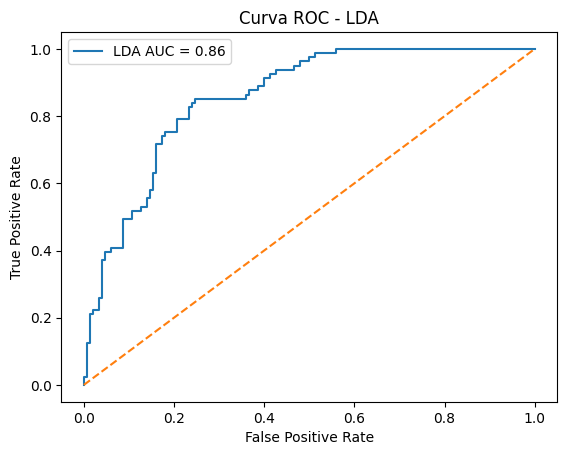

In [48]:
#Curva ROC LDA
lda_prob = lda_model.predict_proba(X_test)[:,1]
fpr_lda, tpr_lda, _ = roc_curve(y_test, lda_prob)
roc_auc_lda = auc(fpr_lda, tpr_lda)
plt.plot(fpr_lda,
         tpr_lda,
         label=f"LDA AUC = {roc_auc_lda:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - LDA")
plt.legend()
plt.show()

## **Paso 7.** Evaluación del desempeño de QDA
Se evalúa el modelo con:

- Accuracy
- Precision
- Recall
- F1-score
- Matriz de confusión
- Curva ROC
- AUC

**Pregunta 13.** Compara las métricas de QDA con las de LDA. ¿Qué métrica consideras más importante en este problema?

> Escribe tu respuesta aquí:  LDA tuvo un desempeño mejor que QDA en accuracy, precision, recall, F1-score y AUC.el mas importante es el recall porque permite identificar a la mayor cantidad posible de pacientes con diabetes y reducir los falsos negativos


#### Matriz de confusión

In [53]:
# Matriz de confusión QDA
cm_qda = pd.crosstab(
    y_test,
    qda_pred,
    rownames=['Real'],
    colnames=['Predicción']
)

cm_qda

Predicción,0,1
Real,,
0,131,19
1,40,41


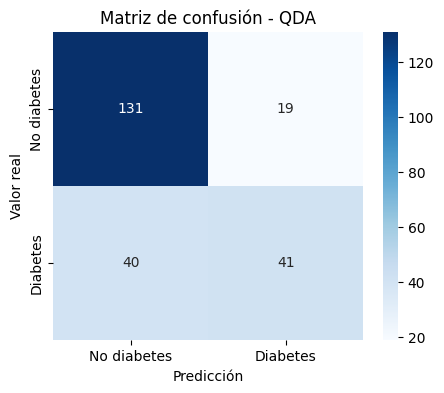

In [54]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_qda,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No diabetes", "Diabetes"],
    yticklabels=["No diabetes", "Diabetes"]
)

plt.title("Matriz de confusión - QDA")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

#### Métricas QDA

In [55]:
#Métricas QDA

exactitud_qda = accuracy_score(y_test, qda_pred)
precision_qda = precision_score(y_test, qda_pred)
sensibilidad_qda = recall_score(y_test, qda_pred) # También llamado Recall
f1_qda = f1_score(y_test, qda_pred)

print("--- Métricas de Evaluación ---")
print(f"Exactitud (Accuracy):  {exactitud_qda:.4f}")
print(f"Precisión:             {precision_qda:.4f}")
print(f"Sensibilidad (Recall): {sensibilidad_qda:.4f}")
print(f"Puntuación F1:         {f1_qda:.4f}")

--- Métricas de Evaluación ---
Exactitud (Accuracy):  0.7446
Precisión:             0.6833
Sensibilidad (Recall): 0.5062
Puntuación F1:         0.5816


#### Reporte QDA

In [57]:
# Clasificación QDA
print("\nReporte QDA")
print(classification_report(y_test, qda_pred))


Reporte QDA
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       150
           1       0.68      0.51      0.58        81

    accuracy                           0.74       231
   macro avg       0.72      0.69      0.70       231
weighted avg       0.74      0.74      0.73       231



#### Curva ROC y AUC

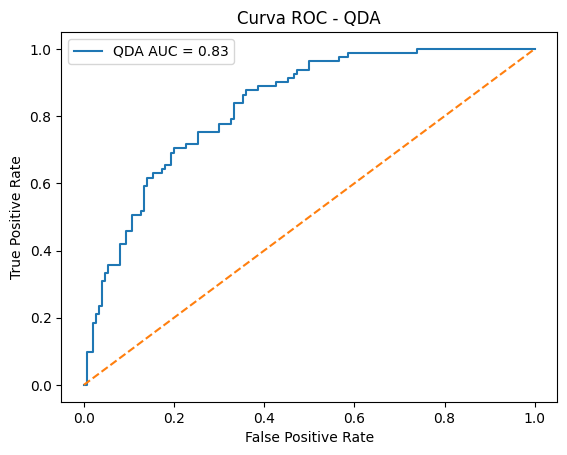

In [58]:
# Curva ROC QDA
qda_prob = qda_model.predict_proba(X_test)[:,1]
fpr_qda, tpr_qda, _ = roc_curve(y_test, qda_prob)
roc_auc_qda = auc(fpr_qda, tpr_qda)
plt.plot(fpr_qda,
         tpr_qda,
         label=f"QDA AUC = {roc_auc_qda:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - QDA")
plt.legend()
plt.show()

## Comparación

**Pregunta 14.** Con base en la tabla de comparación, ¿qué modelo elegirías y por qué?

> Escribe tu respuesta aquí: yo elegiria LDA porque tuvo un mejor desempeño general que QDA Ademas sus metricas fueron ligeramente superiores assi que por eso yo elegiria si duda en LDA


In [59]:
# Comparación
resultados = pd.DataFrame({
    "Modelo": ["LDA", "QDA"],
    "Accuracy": [exactitud_lda, exactitud_qda],
    "Precision": [precision_lda, precision_qda],
    "Recall": [sensibilidad_lda, sensibilidad_qda],
    "F1-score": [f1_lda, f1_qda],
    "AUC": [roc_auc_lda, roc_auc_qda]
})

resultados

,Modelo,Accuracy,Precision,Recall,F1-score,AUC
0,LDA,0.753247,0.700000,0.518519,0.595745,0.856296
1,QDA,0.744589,0.683333,0.506173,0.581560,0.830041


In [60]:
#Mejor modelo
mejor_accuracy = resultados.loc[resultados["Accuracy"].idxmax(), "Modelo"]
mejor_precision = resultados.loc[resultados["Precision"].idxmax(), "Modelo"]
mejor_recall = resultados.loc[resultados["Recall"].idxmax(), "Modelo"]
mejor_f1 = resultados.loc[resultados["F1-score"].idxmax(), "Modelo"]
mejor_auc = resultados.loc[resultados["AUC"].idxmax(), "Modelo"]

print("Mejor modelo según Accuracy:", mejor_accuracy)
print("Mejor modelo según Precision:", mejor_precision)
print("Mejor modelo según Recall:", mejor_recall)
print("Mejor modelo según F1-score:", mejor_f1)
print("Mejor modelo según AUC:", mejor_auc)

Mejor modelo según Accuracy: LDA
Mejor modelo según Precision: LDA
Mejor modelo según Recall: LDA
Mejor modelo según F1-score: LDA
Mejor modelo según AUC: LDA


In [61]:
diferencias = pd.DataFrame({
    "Métrica": ["Accuracy", "Precision", "Recall", "F1-score", "AUC"],
    "LDA": [exactitud_lda, precision_lda, sensibilidad_lda, f1_lda, roc_auc_lda],
    "QDA": [exactitud_qda, precision_qda, sensibilidad_qda, f1_qda, roc_auc_qda]
})

diferencias["Diferencia absoluta"] = abs(diferencias["LDA"]- diferencias["QDA"])

diferencias

,Métrica,LDA,QDA,Diferencia absoluta
0,Accuracy,0.753247,0.744589,0.008658
1,Precision,0.700000,0.683333,0.016667
2,Recall,0.518519,0.506173,0.012346
3,F1-score,0.595745,0.581560,0.014184
4,AUC,0.856296,0.830041,0.026255


In [62]:
criterio_practico = 0.03

diferencias["¿Diferencia práctica importante?"] = diferencias["Diferencia absoluta"].apply(
    lambda x: "Sí" if x >= criterio_practico else "No"
)

diferencias

,Métrica,LDA,QDA,Diferencia absoluta,¿Diferencia práctica importante?
0,Accuracy,0.753247,0.744589,0.008658,No
1,Precision,0.700000,0.683333,0.016667,No
2,Recall,0.518519,0.506173,0.012346,No
3,F1-score,0.595745,0.581560,0.014184,No
4,AUC,0.856296,0.830041,0.026255,No


### Interpretación

Al comparar los modelos LDA y QDA, se observa que el modelo con mejor desempeño según accuracy fue LDA, mientras que el mejor modelo según AUC también fue LDA. La comparación se realizó considerando accuracy, precision, recall, F1-score y AUC.

Desde el punto de vista práctico, la diferencia entre modelos fue de 0.008658008658008698 en accuracy y de 0.02625514403292184 en AUC. Estas diferencias no parecen ser muy grandes desde el punto de vista práctico, ya que ambas son menores a 0.03. Sin embargo, LDA obtuvo mejores resultados en ambas métricas, por lo que puede considerarse una opción más conveniente en este caso, especialmente porque es un modelo más simple e interpretable.

Respecto a la frontera de decisión, los resultados sugieren que la frontera lineal de LDA parece suficiente para este problema. Esto se debe a que QDA, a pesar de ser un modelo más flexible y permitir fronteras cuadráticas, no logró mejorar claramente el desempeño de LDA. Por lo tanto, no parece necesario utilizar una frontera más compleja para clasificar a las pacientes con y sin diabetes.

También se analizó la posibilidad de sobreajuste comparando el desempeño en entrenamiento y prueba. En este caso, QDA podría presentar cierto sobreajuste, ya que su desempeño en entrenamiento fue mayor que en prueba. Esto puede deberse a que QDA es más flexible y estima una matriz de covarianzas diferente para cada clase, lo cual puede hacer que se ajuste demasiado a los datos de entrenamiento.

Finalmente, en el contexto del problema, el error más relevante es el falso negativo. Este ocurre cuando una paciente con diabetes es clasificada como si no tuviera diabetes. Este tipo de error es importante porque podría retrasar la detección o atención de la enfermedad. En los resultados obtenidos, LDA tuvo 39 falsos negativos, mientras que QDA tuvo 40 falsos negativos. Por lo tanto, LDA no solo presentó mejor accuracy y AUC, sino que también cometió ligeramente menos falsos negativos, lo cual refuerza su elección como el modelo más adecuado para este análisis.

### Pregunta final
Redacta tu propia conclusión comparando LDA y QDA. Debes mencionar: accuracy, recall, AUC, falsos positivos, falsos negativos y posible sobreajuste.

> Escribe tu respuesta aquí: LDA fue el modelo mas adecuado para este problema, ya que obtuvo mejores resultados en accuracy, recall y AUC que QDA Ademas presento menos falsos negativos lo cual me parece muy importante porque permite identificar mejor a los pacientes con diabetes
